# Qwen2-VL — Image-Only Fine-Tuning
### No CV pipeline, no attributes — pure visual domain adaptation

Each training sample is simply:
```
System: You are a pedestrian crossing analyst...
User:   [IMAGE]  Question: Will this pedestrian cross the road?
Assistant: crossed        ← or: waited
```
**Why this works:** Qwen2-VL already has strong visual reasoning.
Fine-tuning without attributes means:
- The model adapts to *this domain* (Cairo streets, your image style)
- No contradictions between text attributes and visual content
- Cleaner gradient signal — model learns visual cues, not text shortcuts


## §0 — Install Dependencies

In [ ]:
!pip install torch torchvision --quiet
!pip install transformers accelerate peft trl bitsandbytes --quiet
!pip install scikit-learn pandas numpy --quiet
print("Dependencies installed ✓")

Dependencies installed ✓


## §1 — Imports & Global Config

In [ ]:
import os, gc, time, warnings
import numpy as np
import pandas as pd
import torch
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
from transformers import (
    Qwen2VLForConditionalGeneration, Qwen2VLProcessor,
    BitsAndBytesConfig, TrainingArguments, Trainer, EarlyStoppingCallback,
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

warnings.filterwarnings('ignore')
os.environ["WANDB_DISABLED"] = "true"

SEED = 42
def set_seed(s=SEED):
    import random; random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
set_seed()

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {DEVICE}  |  PyTorch: {torch.__version__}")
if DEVICE == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}"
          f"  VRAM: {torch.cuda.get_device_properties(0).total_memory/1024**3:.1f}GB")

Device: cuda  |  PyTorch: 2.11.0+cu128
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition  VRAM: 95.0GB


## §2 — Paths & Hyperparameters

In [ ]:
from google.colab import drive
if not os.path.isdir('/content/drive/MyDrive'):
    drive.mount('/content/drive')
else:
    print('Drive already mounted.')

# ── Adjust to your Drive layout ──────────────────────────────────────────
DATASET_ROOT = '/content/drive/MyDrive/GIU.Master/EgyptPedestriansDataset_v2'
SUMMARY_CSV  = os.path.join(DATASET_ROOT, 'dataset_summary.csv')
CROSSED_DIR  = os.path.join(DATASET_ROOT, 'crossed', 'crossed')
WAITED_DIR   = os.path.join(DATASET_ROOT, 'crossed', 'waited')

OUTPUT_DIR   = '/content/output/qwen_image_only'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Model & training hyperparameters ─────────────────────────────────────
MODEL_ID      = 'Qwen/Qwen2-VL-7B-Instruct'
EPOCHS        = 3
BATCH_SIZE    = 1
GRAD_ACCUM    = 4          # effective batch = 4
LEARNING_RATE = 2e-4
MAX_SEQ_LEN   = 1024       # image+short-text fits in 1024
WARMUP_STEPS  = 10
MAX_GRAD_NORM = 1.0
OPTIM         = 'paged_adamw_32bit'

# ── LoRA config ───────────────────────────────────────────────────────────
LORA_R       = 16
LORA_ALPHA   = 32
LORA_DROPOUT = 0.05

print("Config ready ✓")

Mounted at /content/drive
Config ready ✓


## §3 — Data Loading

We read `dataset_summary.csv`, keep only the `crossed` feature rows (which hold the crossing label), locate each image on disk, and deduplicate to one track per pedestrian to avoid leakage.

In [ ]:
def find_image_path(img_name):
    for folder, lbl in [(CROSSED_DIR, 'crossed'), (WAITED_DIR, 'waited')]:
        p = os.path.join(folder, img_name)
        if os.path.exists(p):
            return p, lbl
    return None, None

print('Loading dataset_summary.csv...')
df_raw = pd.read_csv(SUMMARY_CSV)
df_raw.columns = df_raw.columns.str.lower()

# Keep only crossing-label rows
df_cross = df_raw[df_raw['feature'] == 'crossed'][['img_name', 'label']].copy()

# Locate image files
df_cross['img_path'], df_cross['label'] = zip(
    *df_cross['img_name'].apply(find_image_path))
df_cross = df_cross[df_cross['img_path'].notna()].copy().reset_index(drop=True)

# Track-level dedup for stratified splitting
df_cross['track_id'] = df_cross['img_name'].apply(
    lambda fn: '_'.join(str(fn).split('_')[:2]))
df_tracks = df_cross.drop_duplicates(subset='track_id', keep='first').reset_index(drop=True)

print(f"Total images  : {len(df_cross)}")
print(f"Unique tracks : {len(df_tracks)}")
print(f"  crossed : {(df_tracks['label']=='crossed').sum()}")
print(f"  waited  : {(df_tracks['label']=='waited').sum()}")

Loading dataset_summary.csv...
Total images  : 2581
Unique tracks : 30
  crossed : 18
  waited  : 12


## §4 — Train / Val / Test Splits (track-level, no leakage)

In [ ]:
y = (df_tracks['label'] == 'crossed').astype(int).values

idx_tv, idx_te = train_test_split(
    np.arange(len(df_tracks)), test_size=0.20, stratify=y, random_state=SEED)
idx_tr, idx_va = train_test_split(
    idx_tv, test_size=0.20/0.80, stratify=y[idx_tv], random_state=SEED)

train_tracks = set(df_tracks.iloc[idx_tr]['track_id'])
val_tracks   = set(df_tracks.iloc[idx_va]['track_id'])
test_tracks  = set(df_tracks.iloc[idx_te]['track_id'])

# Training uses ALL frames of each training track
df_train = df_cross[df_cross['track_id'].isin(train_tracks)].reset_index(drop=True)
# Validation uses ALL frames of each val track
df_val   = df_cross[df_cross['track_id'].isin(val_tracks)].reset_index(drop=True)
# Test uses ONE representative frame per track (no data leakage)
df_test  = df_tracks.iloc[idx_te].reset_index(drop=True)

assert train_tracks.isdisjoint(test_tracks), 'LEAKAGE: train/test tracks overlap!'

print(f"Train : {len(df_train)} frames  "
      f"(crossed:{(df_train['label']=='crossed').sum()}  "
      f"waited:{(df_train['label']=='waited').sum()})")
print(f"Val   : {len(df_val)} frames  "
      f"(crossed:{(df_val['label']=='crossed').sum()}  "
      f"waited:{(df_val['label']=='waited').sum()})")
print(f"Test  : {len(df_test)} tracks  "
      f"(crossed:{(df_test['label']=='crossed').sum()}  "
      f"waited:{(df_test['label']=='waited').sum()})")

Train : 1706 frames  (crossed:1193  waited:513)
Val   : 336 frames  (crossed:221  waited:115)
Test  : 6 tracks  (crossed:4  waited:2)


## §5 — Conversation Format

Each sample is a 3-turn conversation:

| Turn | Role | Content |
|------|------|---------|
| 0 | system | Task description (no attribute hints) |
| 1 | user | `[IMAGE]` + `Question: Will this pedestrian cross the road?` |
| 2 | assistant | `crossed` or `waited` |

The answer is a **single word** — this minimises hallucination risk and makes parsing trivial.

In [ ]:
SYSTEM_PROMPT = (
    'You are a pedestrian crossing behaviour analyst for autonomous vehicles.\n'
    'You are given a single image of a pedestrian at a road crossing.\n'
    'Based only on what you see, decide: did the pedestrian cross or wait?\n'
    'Answer with exactly one word: crossed or waited.'
)

USER_QUESTION = 'Question: Will this pedestrian cross the road?'


def make_train_conversation(img_pil, label: str) -> list:
    """3-turn conversation for training (includes assistant answer)."""
    assert label in ('crossed', 'waited')
    return [
        {'role': 'system',
         'content': [{'type': 'text', 'text': SYSTEM_PROMPT}]},
        {'role': 'user',
         'content': [
             {'type': 'image', 'image': img_pil},
             {'type': 'text',  'text': USER_QUESTION},
         ]},
        {'role': 'assistant',
         'content': [{'type': 'text', 'text': label}]},   # single word
    ]


def make_test_conversation(img_pil) -> list:
    """2-turn conversation for inference (no assistant turn)."""
    return [
        {'role': 'system',
         'content': [{'type': 'text', 'text': SYSTEM_PROMPT}]},
        {'role': 'user',
         'content': [
             {'type': 'image', 'image': img_pil},
             {'type': 'text',  'text': USER_QUESTION},
         ]},
    ]


def df_to_train_convs(df: pd.DataFrame) -> list:
    convs = []
    for _, row in df.iterrows():
        try:
            img = Image.open(row['img_path']).convert('RGB')
            convs.append(make_train_conversation(img, row['label']))
        except Exception as e:
            print(f'  Skip {row["img_path"]}: {e}')
    return convs


print("Conversation builder ready ✓")

Conversation builder ready ✓


## §6 — Build Conversation Datasets

In [ ]:
print('Building training conversations...')
train_convs = df_to_train_convs(df_train)
print(f"  {len(train_convs)} training samples")

print('Building validation conversations...')
val_convs = df_to_train_convs(df_val)
print(f"  {len(val_convs)} validation samples")

print('Building test conversations (inference — no assistant turn)...')
test_convs  = []
test_labels = []
for _, row in df_test.iterrows():
    try:
        img = Image.open(row['img_path']).convert('RGB')
        test_convs.append(make_test_conversation(img))
        test_labels.append(1 if row['label'] == 'crossed' else 0)
    except Exception as e:
        print(f'  Skip {row["img_path"]}: {e}')

print(f"  {len(test_convs)} test samples")
print(f"  crossed: {sum(test_labels)}  waited: {len(test_labels)-sum(test_labels)}")

Building training conversations...
  1706 training samples
Building validation conversations...
  336 validation samples
Building test conversations (inference — no assistant turn)...
  6 test samples
  crossed: 4  waited: 2


## §7 — Load Qwen2-VL-7B in 4-bit NF4 + Attach LoRA

In [ ]:
def load_qwen():
    bnb = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type='nf4',
        bnb_4bit_compute_dtype=torch.bfloat16,
    )
    model = Qwen2VLForConditionalGeneration.from_pretrained(
        MODEL_ID, device_map='auto', quantization_config=bnb)
    model.config.use_cache = False
    processor = Qwen2VLProcessor.from_pretrained(MODEL_ID)
    processor.tokenizer.padding_side = 'right'
    return model, processor

print(f"Loading {MODEL_ID} in 4-bit NF4...")
qwen_model, qwen_processor = load_qwen()
print(f"Loaded. Parameters: {qwen_model.num_parameters():,}")

# Prepare for QLoRA
qwen_model = prepare_model_for_kbit_training(qwen_model)

lora_cfg = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    bias='none',
    target_modules=['q_proj', 'k_proj', 'v_proj', 'o_proj',
                    'gate_proj', 'up_proj', 'down_proj'],
    task_type='CAUSAL_LM',
)
qwen_model = get_peft_model(qwen_model, lora_cfg)
qwen_model._hf_peft_config_loaded = True
qwen_model.print_trainable_parameters()

Loading Qwen/Qwen2-VL-7B-Instruct in 4-bit NF4...


config.json:   0%|          | 0.00/1.20k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/56.5k [00:00<?, ?B/s]

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/730 [00:00<?, ?it/s]

...

tokenizer_config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

Loaded. Parameters: 8,291,375,616
trainable params: 40,370,176 || all params: 8,331,745,792 || trainable%: 0.4845


## §8 — Data Collator & Inference Helper

Key detail: we mask all prompt tokens (`-100`) so the model only learns to predict the single-word answer, not the system/user turns.

In [ ]:
def make_collate_fn(processor):
    """
    Batch conversations into tensors.
    Prompt tokens are masked so loss is computed on the answer only.
    """
    def collate_fn(examples):
        full_texts   = [processor.apply_chat_template(ex, tokenize=False)
                        for ex in examples]
        prompt_texts = [processor.apply_chat_template(
                            ex[:2], tokenize=False, add_generation_prompt=True)
                        for ex in examples]
        images = [ex[1]['content'][0]['image'] for ex in examples]

        batch = processor(
            text=full_texts, images=images,
            return_tensors='pt', padding=True,
            max_length=MAX_SEQ_LEN, truncation=True,
        )
        labels = batch['input_ids'].clone()

        for i, (ptext, img) in enumerate(zip(prompt_texts, images)):
            prompt_enc = processor(
                text=[ptext], images=img,
                return_tensors='pt',
                max_length=MAX_SEQ_LEN, truncation=True,
            )
            prompt_len = prompt_enc['input_ids'].shape[1]
            labels[i, :prompt_len] = -100   # mask prompt

        labels[batch['attention_mask'] == 0] = -100   # mask padding
        batch['labels'] = labels
        return batch
    return collate_fn


def run_inference(model, processor, conv_2turn, max_new_tokens=5):
    """
    Inference on a 2-turn conversation (system + user).
    max_new_tokens=5 is more than enough for a single-word answer.
    """
    text  = processor.apply_chat_template(
        conv_2turn, tokenize=False, add_generation_prompt=True)
    image = conv_2turn[1]['content'][0]['image']
    inputs = processor(
        text=[text], images=image,
        return_tensors='pt', max_length=MAX_SEQ_LEN, truncation=True,
    )
    input_len = inputs['input_ids'].shape[1]
    inputs    = {k: v.to(DEVICE) for k, v in inputs.items()}
    with torch.no_grad():
        gen_ids = model.generate(
            **inputs, max_new_tokens=max_new_tokens,
            do_sample=False, temperature=None, top_p=None,
        )
    new_tokens = gen_ids[:, input_len:]
    output = processor.batch_decode(new_tokens, skip_special_tokens=True)[0]
    del inputs
    return output.strip().lower()


def parse_label(raw: str) -> int:
    """Map model output string to int label. 1=crossed, 0=waited."""
    if 'crossed' in raw:
        return 1
    if 'waited' in raw or 'wait' in raw:
        return 0
    # Unexpected output — default to waited and warn
    print(f'  [parse_label] unexpected: {raw!r} → defaulting to waited')
    return 0


print("Helpers ready ✓")

Helpers ready ✓


## §9 — Baseline Inference (Zero-Shot, Before Fine-Tuning)

In [ ]:
print('=' * 58)
print(' BASELINE — Qwen2-VL zero-shot on 10 test images')
print('=' * 58)

y_before = []
for i, (conv, true_int) in enumerate(zip(test_convs[:10], test_labels[:10])):
    raw  = run_inference(qwen_model, qwen_processor, conv)
    pred = parse_label(raw)
    y_before.append(pred)
    true_lbl = 'crossed' if true_int else 'waited'
    pred_lbl = 'crossed' if pred     else 'waited'
    mark = '✓' if pred == true_int else '✗'
    print(f'  [{mark}] true={true_lbl:<8s}  pred={pred_lbl:<8s}  raw="{raw}"')

baseline_acc = accuracy_score(test_labels[:10], y_before)
print(f"\nBaseline accuracy (10 samples): {baseline_acc:.2f}")

 BASELINE — Qwen2-VL zero-shot on 10 test images
  [✓] true=waited    pred=waited    raw="waited"
  [✗] true=crossed   pred=waited    raw="waited"
  [✗] true=crossed   pred=waited    raw="waited"
  [✗] true=crossed   pred=waited    raw="waited"
  [✗] true=crossed   pred=waited    raw="waited"
  [✓] true=waited    pred=waited    raw="waited"

Baseline accuracy (10 samples): 0.33


## §10 — Fine-Tune with QLoRA

Only the LoRA adapters (~1% of parameters) are updated. The frozen backbone handles visual encoding.

In [ ]:
optimizer_steps = max(
    (len(train_convs) // BATCH_SIZE // GRAD_ACCUM) * EPOCHS, 1)
eval_steps = max(optimizer_steps // 4, 1)
warmup_v   = max(min(WARMUP_STEPS, optimizer_steps // 10), 1)

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    lr_scheduler_type='cosine',
    logging_steps=max(optimizer_steps // 10, 1),
    eval_strategy='steps',  eval_steps=eval_steps,
    save_strategy='steps',  save_steps=eval_steps,
    load_best_model_at_end=True,
    metric_for_best_model='loss',
    greater_is_better=False,
    max_grad_norm=MAX_GRAD_NORM,
    warmup_steps=warmup_v,
    gradient_accumulation_steps=GRAD_ACCUM,
    bf16=True,
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={'use_reentrant': False},
    optim=OPTIM,
    report_to='none',
    remove_unused_columns=False,
    dataloader_num_workers=0,
)

trainer = Trainer(
    model=qwen_model,
    args=training_args,
    train_dataset=train_convs,
    eval_dataset=val_convs,
    data_collator=make_collate_fn(qwen_processor),
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print(f"Train samples  : {len(train_convs)}")
print(f"Val   samples  : {len(val_convs)}")
print(f"Optimizer steps: {optimizer_steps}  (eval every {eval_steps} steps)")
print('\nInitial eval loss:', trainer.evaluate()['eval_loss'])

print('\nFine-tuning Qwen2-VL-7B...')
t0 = time.time()
trainer.train()
print(f"\nDone in {time.time()-t0:.0f}s")

trainer.save_model(OUTPUT_DIR)
print(f"LoRA adapter saved → {OUTPUT_DIR}")

Train samples  : 1706
Val   samples  : 336
Optimizer steps: 1278  (eval every 319 steps)


Training Loss,Validation Loss,Step
No log,0.302357,0


[transformers] `use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.



Initial eval loss: 0.3023567795753479

Fine-tuning Qwen2-VL-7B...


Step,Training Loss,Validation Loss
319,0.040873,0.318613
638,0.011000,0.355781
957,0.000718,0.661888



Done in 1180s
LoRA adapter saved → /content/output/qwen_image_only


## §11 — Evaluation After Fine-Tuning

In [ ]:
print('=' * 58)
print(' AFTER FINE-TUNING — full test set')
print('=' * 58)

y_after = []
for i, (conv, true_int) in enumerate(zip(test_convs, test_labels)):
    raw  = run_inference(qwen_model, qwen_processor, conv)
    pred = parse_label(raw)
    y_after.append(pred)
    if i < 10:   # print first 10 for a quick sanity check
        mark = '✓' if pred == true_int else '✗'
        print(f'  [{mark}] true={"crossed" if true_int else "waited":<8s}  '
              f'pred={"crossed" if pred else "waited":<8s}  raw="{raw}"')

print('\n' + classification_report(
    test_labels, y_after, target_names=['waited', 'crossed']))
print(f"Accuracy : {accuracy_score(test_labels, y_after):.4f}")
print(f"F1 macro : {f1_score(test_labels, y_after, average='macro'):.4f}")

if 'baseline_acc' in dir():
    print(f"\nBaseline (zero-shot, 10 samples) : {baseline_acc:.2f}")
    print(f"After FT (full test set)          : {accuracy_score(test_labels, y_after):.2f}")

 AFTER FINE-TUNING — full test set
  [✗] true=waited    pred=crossed   raw="crossed"
  [✓] true=crossed   pred=crossed   raw="crossed"
  [✓] true=crossed   pred=crossed   raw="crossed"
  [✓] true=crossed   pred=crossed   raw="crossed"
  [✓] true=crossed   pred=crossed   raw="crossed"
  [✓] true=waited    pred=waited    raw="waited"

              precision    recall  f1-score   support

      waited       1.00      0.50      0.67         2
     crossed       0.80      1.00      0.89         4

    accuracy                           0.83         6
   macro avg       0.90      0.75      0.78         6
weighted avg       0.87      0.83      0.81         6

Accuracy : 0.8333
F1 macro : 0.7778

Baseline (zero-shot, 10 samples) : 0.33
After FT (full test set)          : 0.83


## §12 — Save Results CSV

In [ ]:
rows = []
for (_, row), pred_int in zip(df_test.iterrows(), y_after):
    pred_lbl = 'crossed' if pred_int else 'waited'
    rows.append({
        'track_id'  : row['track_id'],
        'img_name'  : row['img_name'],
        'true_label': row['label'],
        'pred_label': pred_lbl,
        'correct'   : int(row['label'] == pred_lbl),
    })
df_results = pd.DataFrame(rows)
out_path   = os.path.join(OUTPUT_DIR, 'test_results.csv')
df_results.to_csv(out_path, index=False)
print(f"Results saved → {out_path}")
print(df_results.head(10))

Results saved → /content/output/qwen_image_only/test_results.csv
  track_id          img_name true_label pred_label  correct
0    V4_t7    V4_t7_f502.jpg     waited    crossed        0
1   V4_t17  V4_t17_f1090.jpg    crossed    crossed        1
2    V4_t9    V4_t9_f614.jpg    crossed    crossed        1
3   V3_t13  V3_t13_f3240.jpg    crossed    crossed        1
4   V4_t10   V4_t10_f617.jpg    crossed    crossed        1
5   V4_t15  V4_t15_f1087.jpg     waited     waited        1


In [ ]:
# ── Alternative — Copy Model Straight to Google Drive (recommended for ~16GB) ──
import os, shutil
from google.colab import drive

if not os.path.isdir('/content/drive/MyDrive'):
    drive.mount('/content/drive')

os.environ['HF_HOME'] = '/content/hf_cache'
os.makedirs('/content/hf_cache', exist_ok=True)

!pip install -q hf_transfer
os.environ['HF_HUB_ENABLE_HF_TRANSFER'] = '1'

from huggingface_hub import snapshot_download

print(f"Downloading {MODEL_ID} ...")
local_path = snapshot_download(
    repo_id=MODEL_ID,
    cache_dir=os.environ['HF_HOME'],
    ignore_patterns=['.bin', '.msgpack', '.h5', '.onnx', 'onnx'],
)
print(f"Downloaded to: {local_path}")

drive_dest = '/content/drive/MyDrive/Qwen2-VL-7B-Instruct'
print(f"Copying to Drive: {drive_dest} ...")
shutil.copytree(local_path, drive_dest, dirs_exist_ok=True)
print("Done. Model is now in your Drive — reuse anytime without re-downloading:")
print(f"  MODEL_ID = '{drive_dest}'")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 41.9 MB/s eta 0:00:00


Fetching 17 files:   0%|          | 0/17 [00:00<?, ?it/s]

Downloaded to: /content/hf_cache/models--Qwen--Qwen2-VL-7B-Instruct/snapshots/eed13092ef92e448dd6875b2a00151bd3f7db0ac
Copying to Drive: /content/drive/MyDrive/Qwen2-VL-7B-Instruct ...
Done. Model is now in your Drive — reuse anytime without re-downloading:
  MODEL_ID = '/content/drive/MyDrive/Qwen2-VL-7B-Instruct'


In [ ]:
# ── §6b — Download Qwen2-VL-7B, Zip It, and Get a Download Link ──────────
import os, shutil

# Download to LOCAL Colab disk (not Drive) so we have room to zip too
os.environ['HF_HOME'] = '/content/hf_cache'
os.makedirs('/content/hf_cache', exist_ok=True)

!pip install -q hf_transfer
os.environ['HF_HUB_ENABLE_HF_TRANSFER'] = '1'

from huggingface_hub import snapshot_download

print(f"Downloading {MODEL_ID} ...")
local_path = snapshot_download(
    repo_id=MODEL_ID,
    cache_dir=os.environ['HF_HOME'],
    ignore_patterns=['.bin', '.msgpack', '.h5', '.onnx', 'onnx'],
)
print(f"Downloaded to: {local_path}")

# Check we have enough free space to also hold the zip (~16GB again)
total, used, free = shutil.disk_usage('/content')
print(f"Free space before zipping: {free / 1024**3:.1f} GB")
if free / 1024**3 < 18:
    print("⚠️  WARNING: may not have enough room to zip safely. "
          "Consider the Drive-copy alternative instead.")

zip_path = '/content/qwen2vl_7b_instruct.zip'
print("Zipping (this takes a while for ~16GB)...")
shutil.make_archive(
    base_name=zip_path.replace('.zip', ''),  # shutil appends .zip
    format='zip',
    root_dir=local_path,
)
print(f"Zip created: {zip_path}  ({os.path.getsize(zip_path) / 1024**3:.1f} GB)")

# Trigger browser download
from google.colab import files
files.download(zip_path)

Fetching 17 files:   0%|          | 0/17 [00:00<?, ?it/s]

Downloaded to: /content/hf_cache/models--Qwen--Qwen2-VL-7B-Instruct/snapshots/eed13092ef92e448dd6875b2a00151bd3f7db0ac
Free space before zipping: 140.1 GB
Zipping (this takes a while for ~16GB)...
Zip created: /content/qwen2vl_7b_instruct.zip  (12.2 GB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ── Copy Already-Downloaded Model to Google Drive (robust version) ────────
import os, shutil
from google.colab import drive

if not os.path.isdir('/content/drive/MyDrive'):
    drive.mount('/content/drive')
else:
    print('Drive already mounted.')

# Let huggingface_hub itself resolve the local snapshot path —
# this works regardless of internal cache layout (xet, symlinks, etc.)
from huggingface_hub import snapshot_download

local_path = snapshot_download(
    repo_id=MODEL_ID,
    cache_dir=os.environ.get('HF_HOME', '/content/hf_cache'),
    local_files_only=True,   # don't re-download, just resolve the path
)
print(f"Found model at: {local_path}")

# Check Drive free space before copying
total, used, free = shutil.disk_usage('/content/drive/MyDrive')
size_needed = sum(
    os.path.getsize(os.path.join(dp, f))
    for dp, _, files in os.walk(local_path, followlinks=True)
    for f in files
)
print(f"Model size: {size_needed / 1024**3:.1f} GB")
print(f"Drive free space: {free / 1024**3:.1f} GB")

drive_dest = '/content/drive/MyDrive/Master Project /GIU Master Thesis/Qwen2-VL-7B-Instruct'
print(f"\nCopying to Drive: {drive_dest} ...")
shutil.copytree(local_path, drive_dest, dirs_exist_ok=True, symlinks=False)

print("\n✅ Done. Reuse next time without re-downloading by setting:")
print(f"  MODEL_ID = '{drive_dest}'")

Drive already mounted.
Found model at: /content/hf_cache/models--Qwen--Qwen2-VL-7B-Instruct/snapshots/eed13092ef92e448dd6875b2a00151bd3f7db0ac
Model size: 15.5 GB
Drive free space: 69.6 GB

Copying to Drive: /content/drive/MyDrive/Master Project /GIU Master Thesis/Qwen2-VL-7B-Instruct ...

✅ Done. Reuse next time without re-downloading by setting:
  MODEL_ID = '/content/drive/MyDrive/Master Project /GIU Master Thesis/Qwen2-VL-7B-Instruct'


Base model (Drive): /content/drive/MyDrive/Master Project /GIU Master Thesis/Qwen2-VL-7B-Instruct
LoRA adapter found: True  (/content/output/qwen_image_only)

Loading BASE model (before fine-tuning) ...


Loading weights:   0%|          | 0/730 [00:00<?, ?it/s]

Base model loaded ✓

Loading FINE-TUNED model (base + LoRA adapter) ...
Fine-tuned model loaded ✓

No custom path given — using random test-set image #5 (true label: waited)


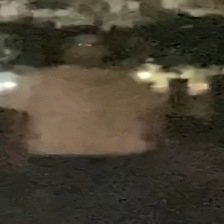


 PREDICTION COMPARISON
  BASE   (before fine-tuning): waited
  TUNED  (after fine-tuning):  waited


In [ ]:
# ── Load Model From Drive (Base + Fine-Tuned) & Test on a Real Image ──────
import os, torch
from PIL import Image
from transformers import Qwen2VLForConditionalGeneration, Qwen2VLProcessor, BitsAndBytesConfig
from peft import PeftModel

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# ── 1) Path to the base model saved in Drive ───────────────────────────────
DRIVE_MODEL_PATH = '/content/drive/MyDrive/Master Project /GIU Master Thesis/Qwen2-VL-7B-Instruct'
assert os.path.isdir(DRIVE_MODEL_PATH), f"Not found: {DRIVE_MODEL_PATH} — mount Drive first."

# ── 2) Path to your fine-tuned LoRA adapter (set after training) ──────────
ADAPTER_PATH = OUTPUT_DIR if 'OUTPUT_DIR' in dir() else '/content/output/qwen_image_only'
HAS_ADAPTER  = os.path.isdir(ADAPTER_PATH) and any(
    f.startswith('adapter') for f in os.listdir(ADAPTER_PATH)
) if os.path.isdir(ADAPTER_PATH) else False

print(f"Base model (Drive): {DRIVE_MODEL_PATH}")
print(f"LoRA adapter found: {HAS_ADAPTER}  ({ADAPTER_PATH})")


def load_base_model():
    bnb = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type='nf4',
        bnb_4bit_compute_dtype=torch.bfloat16,
    )
    model = Qwen2VLForConditionalGeneration.from_pretrained(
        DRIVE_MODEL_PATH, device_map='auto', quantization_config=bnb,
    )
    model.config.use_cache = True  # fine for inference (was False during training)
    processor = Qwen2VLProcessor.from_pretrained(DRIVE_MODEL_PATH)
    return model, processor


print("\nLoading BASE model (before fine-tuning) ...")
base_model, processor = load_base_model()
print("Base model loaded ✓")

ft_model = None
if HAS_ADAPTER:
    print("\nLoading FINE-TUNED model (base + LoRA adapter) ...")
    ft_model = PeftModel.from_pretrained(base_model, ADAPTER_PATH)
    ft_model.eval()
    print("Fine-tuned model loaded ✓")
else:
    print("\n⚠️  No fine-tuned adapter found — only the base model will be tested.")


# ── 3) Inference helper (matches the notebook's conversation format) ──────
def predict(model, processor, image: Image.Image, max_new_tokens=5):
    conv = [
        {'role': 'system',
         'content': [{'type': 'text', 'text': SYSTEM_PROMPT}]},
        {'role': 'user',
         'content': [
             {'type': 'image', 'image': image},
             {'type': 'text',  'text': USER_QUESTION},
         ]},
    ]
    text  = processor.apply_chat_template(conv, tokenize=False, add_generation_prompt=True)
    inputs = processor(text=[text], images=image, return_tensors='pt',
                        max_length=MAX_SEQ_LEN, truncation=True)
    input_len = inputs['input_ids'].shape[1]
    inputs    = {k: v.to(DEVICE) for k, v in inputs.items()}
    with torch.no_grad():
        gen_ids = model.generate(
            **inputs, max_new_tokens=max_new_tokens,
            do_sample=False, temperature=None, top_p=None,
        )
    raw = processor.batch_decode(gen_ids[:, input_len:], skip_special_tokens=True)[0]
    return raw.strip().lower()


# ── 4) Test on a real image ────────────────────────────────────────────────
# Option A: give a specific path
TEST_IMAGE_PATH = ''   # e.g. '/content/drive/MyDrive/.../some_image.jpg'

# Option B: fall back to a random test-set image if no path given
if TEST_IMAGE_PATH and os.path.exists(TEST_IMAGE_PATH):
    test_img = Image.open(TEST_IMAGE_PATH).convert('RGB')
    print(f"\nUsing custom image: {TEST_IMAGE_PATH}")
else:
    import random
    idx = random.randrange(len(test_convs))
    test_img   = test_convs[idx][1]['content'][0]['image']
    true_label = 'crossed' if test_labels[idx] else 'waited'
    print(f"\nNo custom path given — using random test-set image #{idx} (true label: {true_label})")

display(test_img)

print("\n" + "=" * 58)
print(" PREDICTION COMPARISON")
print("=" * 58)

base_pred = predict(base_model, processor, test_img)
print(f"  BASE   (before fine-tuning): {base_pred}")

if ft_model is not None:
    ft_pred = predict(ft_model, processor, test_img)
    print(f"  TUNED  (after fine-tuning):  {ft_pred}")
else:
    print("  TUNED  (after fine-tuning):  [skipped — no adapter found]")

test_convs has 6 samples — showing 6


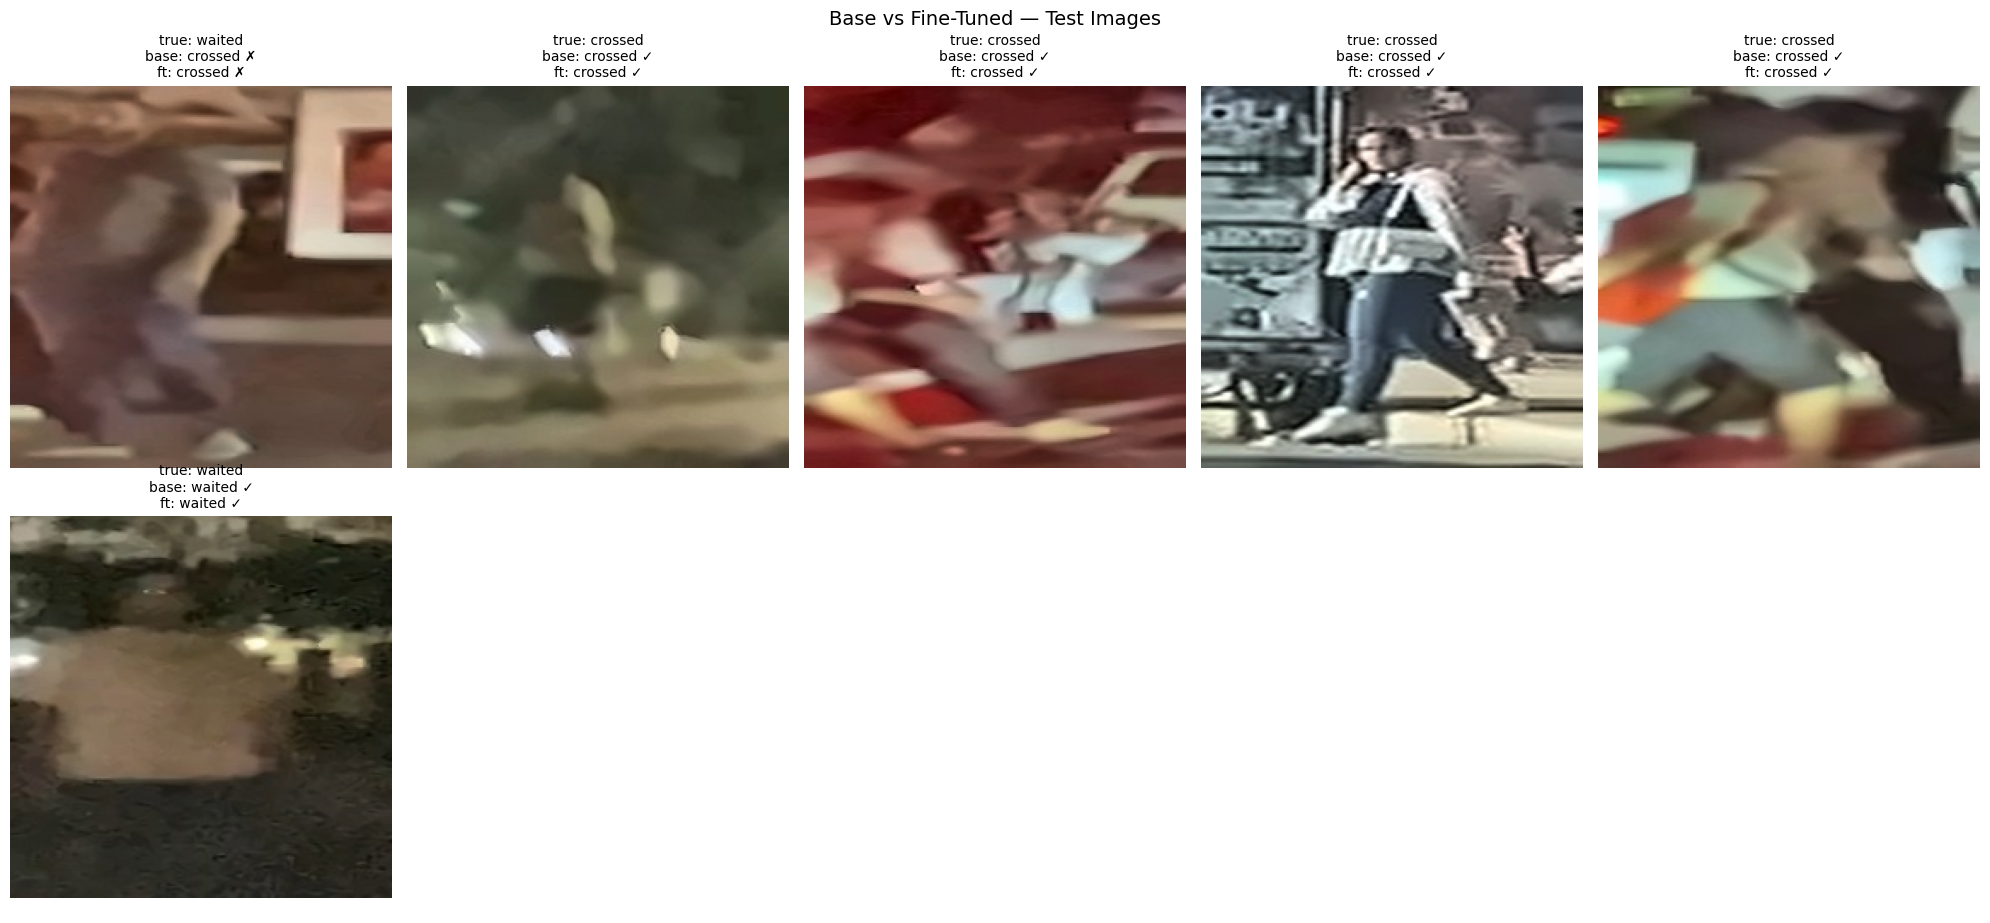

 BASE MODEL (before fine-tuning) — full test set
  [✗] true=waited    pred=crossed   raw="crossed"
  [✓] true=crossed   pred=crossed   raw="crossed"
  [✓] true=crossed   pred=crossed   raw="crossed"
  [✓] true=crossed   pred=crossed   raw="crossed"
  [✓] true=crossed   pred=crossed   raw="crossed"
  [✓] true=waited    pred=waited    raw="waited"

              precision    recall  f1-score   support

      waited       1.00      0.50      0.67         2
     crossed       0.80      1.00      0.89         4

    accuracy                           0.83         6
   macro avg       0.90      0.75      0.78         6
weighted avg       0.87      0.83      0.81         6

Accuracy : 0.8333
F1 macro : 0.7778

 FINE-TUNED MODEL (after fine-tuning) — full test set
  [✗] true=waited    pred=crossed   raw="crossed"
  [✓] true=crossed   pred=crossed   raw="crossed"
  [✓] true=crossed   pred=crossed   raw="crossed"
  [✓] true=crossed   pred=crossed   raw="crossed"
  [✓] true=crossed   pred=crossed

In [ ]:
# ── Visual Test (fixed for small test sets) + Full Eval on base_model & ft_model ──
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, classification_report

def predict_label(model, processor, image, max_new_tokens=5):
    """Run inference and return (pred_int, raw_text)."""
    raw = predict(model, processor, image, max_new_tokens=max_new_tokens)
    if 'crossed' in raw:
        pred = 1
    elif 'waited' in raw or 'wait' in raw:
        pred = 0
    else:
        pred = 0
    return pred, raw


# ── 1) Visual grid — clamped to however many test images actually exist ───
N_SHOW = min(10, len(test_convs))
print(f"test_convs has {len(test_convs)} samples — showing {N_SHOW}")

n_cols = min(5, N_SHOW)
n_rows = (N_SHOW + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4.5 * n_rows))
axes = axes.flatten() if N_SHOW > 1 else [axes]

for i in range(N_SHOW):
    conv, true_int = test_convs[i], test_labels[i]
    img = conv[1]['content'][0]['image']
    true_lbl = 'crossed' if true_int else 'waited'

    base_pred, base_raw = predict_label(base_model, processor, img)
    base_lbl = 'crossed' if base_pred else 'waited'

    if ft_model is not None:
        ft_pred, ft_raw = predict_label(ft_model, processor, img)
        ft_lbl = 'crossed' if ft_pred else 'waited'
    else:
        ft_lbl = 'N/A'

    ax = axes[i]
    ax.imshow(img)
    ax.axis('off')
    base_mark = '✓' if base_pred == true_int else '✗'
    ft_mark   = '✓' if (ft_model is not None and ft_pred == true_int) else ('✗' if ft_model is not None else '')
    ax.set_title(f"true: {true_lbl}\nbase: {base_lbl} {base_mark}\nft: {ft_lbl} {ft_mark}", fontsize=10)

# hide any unused subplot slots
for j in range(N_SHOW, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.suptitle("Base vs Fine-Tuned — Test Images", fontsize=14, y=1.02)
plt.show()


# ── 2) BASE model — your exact reference pattern, run on base_model ───────
print('=' * 58)
print(' BASE MODEL (before fine-tuning) — full test set')
print('=' * 58)

y_before = []
for i, (conv, true_int) in enumerate(zip(test_convs, test_labels)):
    raw  = predict(base_model, processor, conv[1]['content'][0]['image'])
    pred = 1 if 'crossed' in raw else 0
    y_before.append(pred)
    if i < 10:
        mark = '✓' if pred == true_int else '✗'
        print(f'  [{mark}] true={"crossed" if true_int else "waited":<8s}  '
              f'pred={"crossed" if pred else "waited":<8s}  raw="{raw}"')

print('\n' + classification_report(test_labels, y_before, target_names=['waited', 'crossed']))
base_acc = accuracy_score(test_labels, y_before)
base_f1  = f1_score(test_labels, y_before, average='macro')
print(f"Accuracy : {base_acc:.4f}")
print(f"F1 macro : {base_f1:.4f}")


# ── 3) FINE-TUNED model — same exact pattern, run on ft_model ─────────────
if ft_model is not None:
    print('\n' + '=' * 58)
    print(' FINE-TUNED MODEL (after fine-tuning) — full test set')
    print('=' * 58)

    y_after = []
    for i, (conv, true_int) in enumerate(zip(test_convs, test_labels)):
        raw  = predict(ft_model, processor, conv[1]['content'][0]['image'])
        pred = 1 if 'crossed' in raw else 0
        y_after.append(pred)
        if i < 10:
            mark = '✓' if pred == true_int else '✗'
            print(f'  [{mark}] true={"crossed" if true_int else "waited":<8s}  '
                  f'pred={"crossed" if pred else "waited":<8s}  raw="{raw}"')

    print('\n' + classification_report(test_labels, y_after, target_names=['waited', 'crossed']))
    print(f"Accuracy : {accuracy_score(test_labels, y_after):.4f}")
    print(f"F1 macro : {f1_score(test_labels, y_after, average='macro'):.4f}")

    if 'baseline_acc' in dir():
        print(f"\nBaseline (zero-shot, 10 samples) : {baseline_acc:.2f}")
        print(f"After FT (full test set)          : {accuracy_score(test_labels, y_after):.2f}")
else:
    print("\n⚠️  No fine-tuned adapter loaded — skipping fine-tuned evaluation.")

In [ ]:
print(type(base_model))
print(type(ft_model))
print(ft_model is not None)

<class 'transformers.models.qwen2_vl.modeling_qwen2_vl.Qwen2VLForConditionalGeneration'>
<class 'peft.peft_model.PeftModelForCausalLM'>
True


Copying adapter to Drive...


FileNotFoundError: [Errno 2] No such file or directory: '/content/output/qwen_image_only'